<b>Analysis of user behavior in a food retail app</b>

The purpose of the study is to understand user behavior to identify the steps at which users drop off, and to investigate the need for font changes based on A/A/B testing.

We need to understand how users of a mobile grocery app behave.

To do this, we will first study the sales funnel to understand how and in what numbers users reach the point of purchase.

We will then analyze the results of an A/A/B experiment to change the font throughout the app. Users were divided into three groups: two control groups with the old fonts and one experimental group with the new fonts. We will determine which font is better.

**Data Description:**

Each log entry represents a user action, or event.

- `EventName` — the event name;
- `DeviceIDHash` — the unique user identifier;
- `EventTimestamp` — the event time;
- `ExpId` — the experiment number: 246 and 247 are the control groups, and 248 is the experimental group.

Let's download the necessary libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np
import math as mth

### Let's open the data file and study the general information.

In [2]:
data = pd.read_csv('/datasets/logs_exp.csv', sep = "\s+")
data.head(10)

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
5,CartScreenAppear,6217807653094995999,1564055323,248
6,OffersScreenAppear,8351860793733343758,1564066242,246
7,MainScreenAppear,5682100281902512875,1564085677,246
8,MainScreenAppear,1850981295691852772,1564086702,247
9,MainScreenAppear,5407636962369102641,1564112112,246


### Let's prepare the data

Let's convert the column names to lowercase to make it nice and clear:

In [3]:
data.columns = data.columns.str.lower()
data = (data
        .rename(columns={'eventname':'event_name', 'deviceidhash':'device_id_hash', 'eventtimestamp': 'event_ts', 'expid': 'exp_id'})
       )
data.head()

,event_name,device_id_hash,event_ts,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


Let's check the lines for obvious duplicates:

In [4]:
data.duplicated().sum()

413

413 absolute duplicates were identified. They must be removed.

In [5]:
data = data.drop_duplicates()
data.duplicated().sum()

0

Let's check the data for missing values:

In [6]:
data.isna().sum()

event_name        0
device_id_hash    0
event_ts          0
exp_id            0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   event_name      243713 non-null  object
 1   device_id_hash  243713 non-null  int64 
 2   event_ts        243713 non-null  int64 
 3   exp_id          243713 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 9.3+ MB


Let's change the data type in the date and time column:

In [8]:
data['event_ts'] = pd.to_datetime(data['event_ts'], unit='s')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   event_name      243713 non-null  object        
 1   device_id_hash  243713 non-null  int64         
 2   event_ts        243713 non-null  datetime64[ns]
 3   exp_id          243713 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 9.3+ MB


In [10]:
data.head()

,event_name,device_id_hash,event_ts,exp_id
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248


Let's add a date column:

In [11]:
data['event_date'] = data['event_ts'].dt.date

In [12]:
data.head()

,event_name,device_id_hash,event_ts,exp_id,event_date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


### Let's study and verify the data

Let's see how many events there are in the log:

In [13]:
data.shape

(243713, 5)

Total number of users in the log:

In [14]:
users_count = data[['device_id_hash']].value_counts().count()
users_count

7551

Average number of events per user:

In [15]:
avg_event_per_user = int(len(data)) / users_count
avg_event_per_user

32.27559263673685

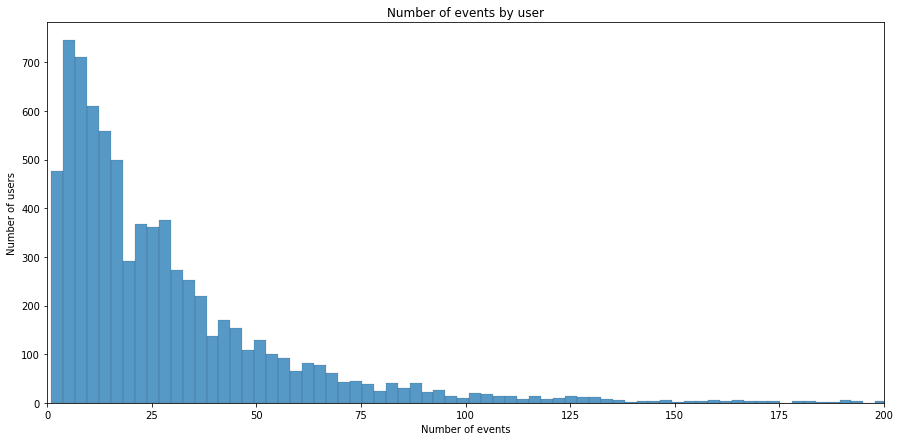

In [16]:
plt.figure(figsize=(15, 7))
sns.histplot(data=data.groupby('device_id_hash')[['event_name']].count(), x='event_name')
plt.title('Number of events by user')
plt.xlabel('Number of events')
plt.ylabel('Number of users')
plt.xlim(0, 200)
plt.show()

In [17]:
data['device_id_hash'].value_counts().describe(percentiles=[0.05, 1/4, 1/2, 3/4, 0.95, 0.99])

count    7551.000000
mean       32.275593
std        65.154219
min         1.000000
5%          3.000000
25%         9.000000
50%        20.000000
75%        37.000000
95%        89.000000
99%       200.500000
max      2307.000000
Name: device_id_hash, dtype: float64

We see that the average number of events per user is 32, and the median is 20. However, only 1% of users completed more than 200 events. The maximum number of events is 2,307, a value too high to account for such a large difference between the average and the median.

What period do we have data for:

In [18]:
data['event_date'].min()

datetime.date(2019, 7, 25)

In [19]:
data['event_date'].max()

datetime.date(2019, 8, 7)

We have data for the period from July 25, 2019 to August 7, 2019.

Let's build a histogram by date and time:

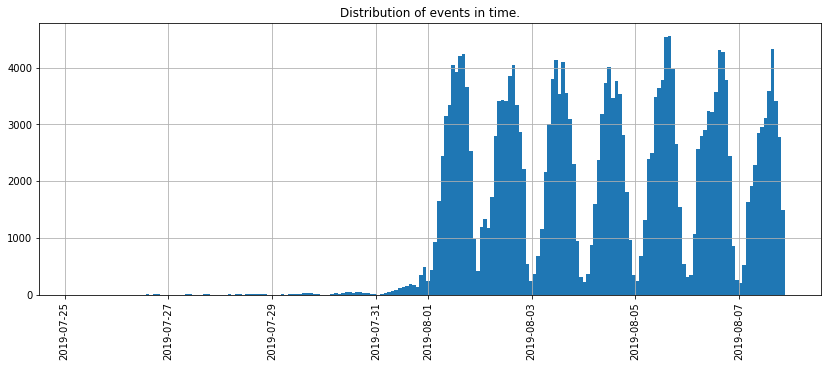

In [54]:
data['event_ts'].hist(bins=200, figsize=(14, 5)).set_title('Distribution of events in time.')
plt.xticks(rotation='vertical');

The histogram shows that the bulk of the data is concentrated in the period from August 1st, which makes it clear that some significant changes have been made since then, and the data from July 25th to August 1st are tails from the past that need to be discarded.

In [21]:
data_full = data.query('event_ts > "2019, 8, 1"')
data_full

,event_name,device_id_hash,event_ts,exp_id,event_date
2828,Tutorial,3737462046622621720,2019-08-01 00:07:28,246,2019-08-01
2829,MainScreenAppear,3737462046622621720,2019-08-01 00:08:00,246,2019-08-01
2830,MainScreenAppear,3737462046622621720,2019-08-01 00:08:55,246,2019-08-01
2831,OffersScreenAppear,3737462046622621720,2019-08-01 00:08:58,246,2019-08-01
2832,MainScreenAppear,1433840883824088890,2019-08-01 00:08:59,247,2019-08-01
...,...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


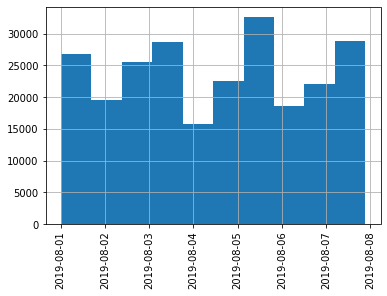

In [22]:
data_full['event_ts'].hist()
plt.xticks(rotation='vertical');

Let's look at the share of events in the remaining period:

In [23]:
ratio_users_full = f'{(len(data_full) / len(data)):.2%}'
ratio_users_full

'98.84%'

Let's calculate the number of users in the remaining period:

In [55]:
print(f'Total users remaining: {len(data_full.device_id_hash.unique())}.')

Total users remaining: 7530.


In [25]:
data_full.groupby('exp_id')['device_id_hash'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: device_id_hash, dtype: int64

We see that 98.43% of all events fall within the remaining period, and 7,530 users out of 7,551 remain—that's almost 99.7%, meaning less than 1% of users are lost, and slightly more than 1% of events are lost. The remaining users are present in all three experimental groups, and the group sizes are approximately equal.

Let's check if we still have users in all three experimental groups:

In [26]:
data_full['exp_id'].value_counts()

248    84563
246    79302
247    77022
Name: exp_id, dtype: int64

Yes, there are approximately the same number of users in all three groups.

### Let's study the event funnel

First, let's check if there are any users who are in multiple groups at the same time:

In [27]:
len(data_full.groupby('device_id_hash')['exp_id'].nunique().reset_index().query('exp_id > 1'))

0

We see that there are no users who are found in several groups.

Let's look at what events are in the logs and how frequently they occur. We'll sort the events by frequency and unique users.

In [28]:
data_full['event_name'].value_counts()

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

Let's look at the popularity of events and the number of users.

Let's count how many users performed each of these events. We'll sort the events by number of users.

In [29]:
events = (data_full
          .groupby('event_name')['device_id_hash']
          .agg(['count', 'nunique'])
          .reset_index()
         )
events.columns =['event_name', 'events_count', 'users_unique']
events = events.sort_values('users_unique', ascending = False)
events

,event_name,events_count,users_unique
1,MainScreenAppear,117328,7419
2,OffersScreenAppear,46333,4593
0,CartScreenAppear,42303,3734
3,PaymentScreenSuccessful,33918,3539
4,Tutorial,1005,840


The most popular event is viewing the main screen. Then, the "Suggestion screen appearance" and "Cart screen appearance" events are about equally popular. The guide is viewed the least, and that's likely by accident.

In [30]:
#users = data_full.groupby('event_name').agg({'device_id_hash': 'nunique'}).sort_values('device_id_hash', ascending = False)
#users

Let's calculate the proportion of users who have performed an event at least once.

In [31]:
events['ratio_users'] = (events['users_unique'] / data.device_id_hash.nunique())
events.style.format({'ratio_users': '{:.2%}'})

,event_name,events_count,users_unique,ratio_users
1,MainScreenAppear,117328,7419,98.25%
2,OffersScreenAppear,46333,4593,60.83%
0,CartScreenAppear,42303,3734,49.45%
3,PaymentScreenSuccessful,33918,3539,46.87%
4,Tutorial,1005,840,11.12%


When loading an app, the first thing a user sees is the home screen, so 98% of users complete this action. The remaining 2% bounce due to technical issues loading the app or close it before it loads. Then, before making a purchase, the user wants to review all the offers, which, as I understand it, is the catalog. It's logical to browse the catalog to select a product. So, 60% of users go to this screen, but for some reason, a fairly large percentage don't make it. I would forward this issue to the testing department after a detailed study of the bounce rates (from which devices and which versions, for example). Next, there's a logical and consistent chain: shopping cart, success page. Almost 47% of users reach the success page from the home page. I mentioned tutorials above – they don't fit into the funnel at all and can be viewed at any time. Therefore, I suggest removing them.

<div id='link'></div>

In [32]:
events_funnel = events.query('event_name != "Tutorial"')
events_funnel.style.format({'ratio_users': '{:.2%}'})

,event_name,events_count,users_unique,ratio_users
1,MainScreenAppear,117328,7419,98.25%
2,OffersScreenAppear,46333,4593,60.83%
0,CartScreenAppear,42303,3734,49.45%
3,PaymentScreenSuccessful,33918,3539,46.87%


In [33]:
data_full = data_full.query('event_name != "Tutorial"')

Let's build a funnel of events:

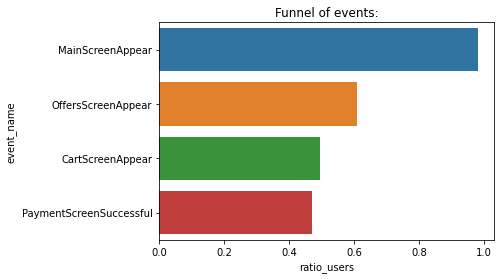

In [56]:
ax = sns.barplot(x = 'ratio_users', y = 'event_name', data = events_funnel.reset_index())
ax.set_title('Funnel of events:');

Now let's divide this funnel into our test groups:

In [35]:
event_pivot = (data_full
               .pivot_table(index=['event_name','exp_id'], values='device_id_hash', aggfunc=['count', 'nunique'])
               .reset_index()
              )
event_pivot.columns= ['event_name','exp_id', 'events_count', 'users_unique']
event_pivot

,event_name,exp_id,events_count,users_unique
0,CartScreenAppear,246,14690,1266
1,CartScreenAppear,247,12434,1238
2,CartScreenAppear,248,15179,1230
3,MainScreenAppear,246,37676,2450
4,MainScreenAppear,247,39090,2476
5,MainScreenAppear,248,40562,2493
6,OffersScreenAppear,246,14767,1542
7,OffersScreenAppear,247,15179,1520
8,OffersScreenAppear,248,16387,1531
9,PaymentScreenSuccessful,246,11852,1200


Let's build a funnel and label the number of users in each group:

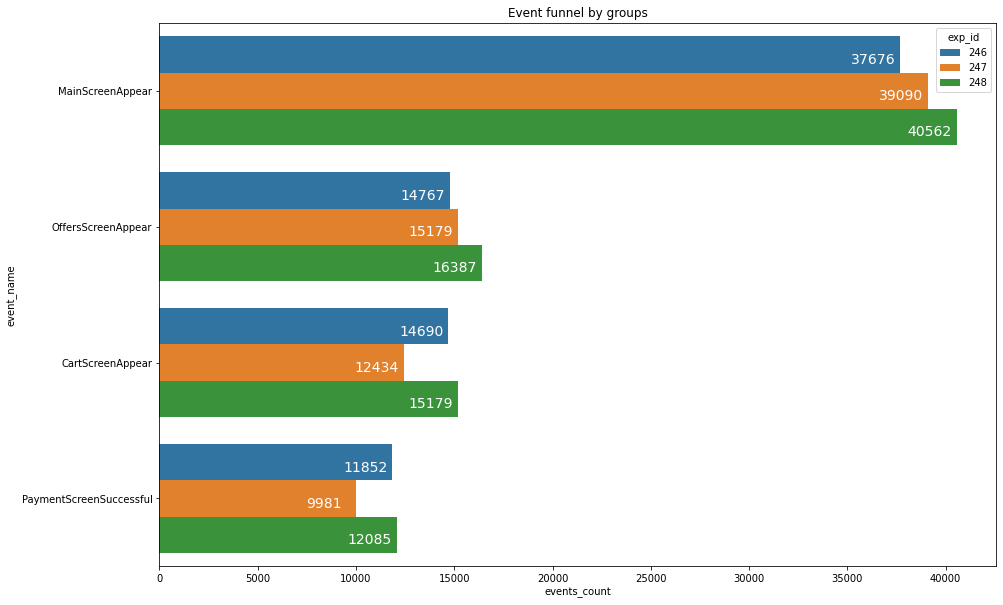

In [57]:
plt.figure(figsize = (15, 10))
sorting = events.query('event_name != "Tutorial"').sort_values('events_count', ascending = False).reset_index(drop = True)['event_name']
ax = sns.barplot(y = 'event_name', x = 'events_count', order = sorting, hue = 'exp_id', data = event_pivot)
ax.set_title('Event funnel by groups')
for i in ax.patches:
    if i.get_width() > 9000:
        ax.text(i.get_width()-2500, i.get_y()+0.2, 
                str(int(i.get_width())), fontsize=14, color='white')
    else:
        ax.text(i.get_width()+30, i.get_y()+0.2, 
                str(int(i.get_width())), fontsize=14, color='black')
plt.show()

Using the event funnel, we will calculate what proportion of users proceed to the next step of the funnel (from the number of users at the previous step).

In [37]:
(events_funnel
     .sort_values('users_unique', ascending=False)['users_unique']
     .pct_change()
     .abs()
     .map(lambda n: '{:,.2%}'.format(n))
     )

1      nan%
2    38.09%
0    18.70%
3     5.22%
Name: users_unique, dtype: object

In [38]:
#ab = round((events_funnel['users_unique'][1] / events_funnel['users_unique'][0]) * 100, 2)
#bc = round((events_funnel['users_unique'][2] / events_funnel['users_unique'][1]) * 100, 2)
#cd = round((events_funnel['users_unique'][3] / events_funnel['users_unique'][2]) * 100, 2)
#print(ab, bc, cd)

We see that the largest number of users (slightly more than 37%) are lost during the transition from the homepage to the catalog browsing page. From the catalog to the shopping cart, 11.4% of users are lost, and from the shopping cart to successful payment, approximately 2.6% are lost.

### Let's study the results of the experiment

Let's look again at how many users are in each experimental group:

In [39]:
users_group = data_full.groupby('exp_id')['device_id_hash'].agg(['count', 'nunique']).reset_index()
users_group.columns =['group', 'events_count', 'users_unique']
users_group

,group,events_count,users_unique
0,246,78985,2483
1,247,76684,2512
2,248,84213,2535


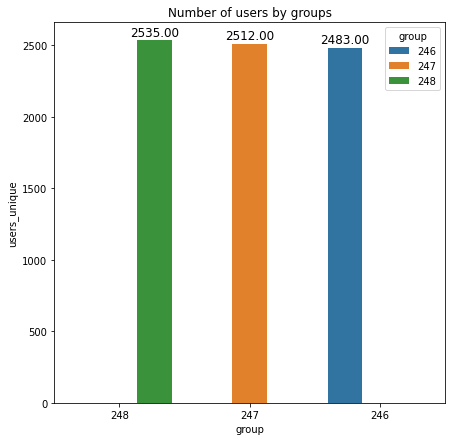

In [58]:
plt.figure(figsize = (7, 7))
sorting = users_group.sort_values('users_unique', ascending = False).reset_index(drop = True)['group']
ax = sns.barplot(y = 'users_unique', x = 'group', order = sorting, hue = 'group', data = users_group)
ax.set_title('Number of users by groups')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.2f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=12, xytext=(0, 8),
                   textcoords='offset points')
plt.show()

There are two control groups for the A/A experiment to verify the validity of all mechanisms and calculations. We will check whether statistical tests detect a difference between samples 246 and 247.

The table shows that each experimental group had roughly the same number of users. Let's isolate and examine in more detail how our groups differ:

In [59]:
group_246 = data_full.query('exp_id == 246').groupby('exp_id')['device_id_hash'].nunique().reset_index()
group_247 = data_full.query('exp_id == 247').groupby('exp_id')['device_id_hash'].nunique().reset_index()
difference = 1 - group_246.iloc[0]['device_id_hash'] / group_247.iloc[0]['device_id_hash']
print('The difference between samples 246 and 247 is {:.2%}'.format(difference))

The difference between samples 246 and 247 is 1.15%


The theory states that the difference in user numbers shouldn't exceed 1% for a successful A/A test. Our difference is negligible, so we believe the accuracy is sufficient for the experiment.

Let's select the most popular event. Count the number of users who performed this event in each control group. Calculate the proportion of users who performed this event. Check whether the difference between the groups is statistically significant. Do the same for all other events (it's convenient to wrap the check in a separate function). Can we say that the grouping is working correctly?

Let's see how many users from each group performed each event:

In [42]:
exp_table = (data_full
             .pivot_table(index='event_name', columns='exp_id', values='device_id_hash', aggfunc='nunique')
            )
exp_table

exp_id,246,247,248
event_name,,,
CartScreenAppear,1266,1238,1230
MainScreenAppear,2450,2476,2493
OffersScreenAppear,1542,1520,1531
PaymentScreenSuccessful,1200,1158,1181


Now, for clarity, let's build a user funnel by events, divided into groups:

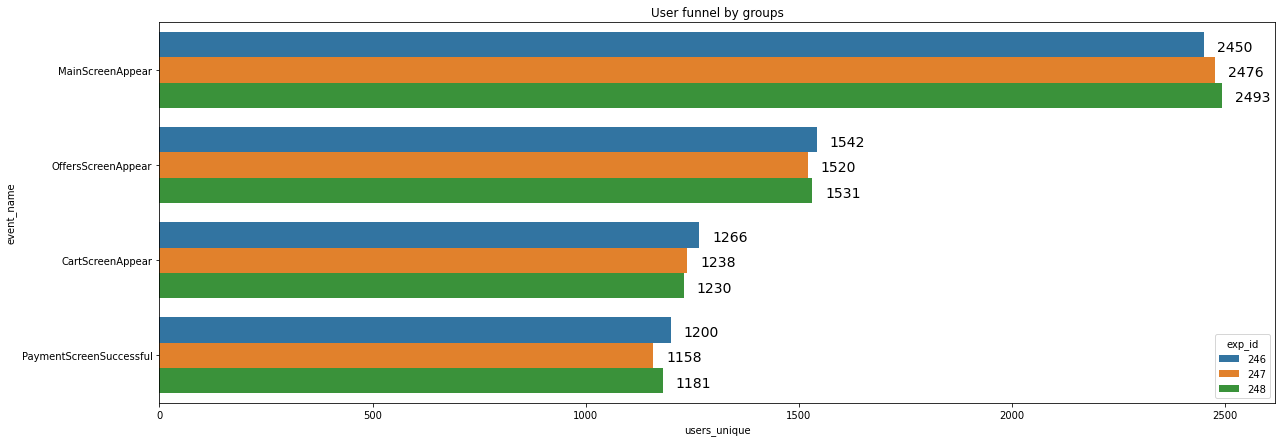

In [60]:
plt.figure(figsize = (20, 7))
sorting = (events
           .query('event_name != "Tutorial"')
           .sort_values('users_unique', ascending = False)
           .reset_index(drop = True)['event_name']
          )
ax = sns.barplot(y = 'event_name', x = 'users_unique', order = sorting, hue = 'exp_id', data = event_pivot)
ax.set_title('User funnel by groups')
for i in ax.patches:
    if i.get_width() > 9000:
        ax.text(i.get_width()-2500, i.get_y()+0.2, 
                str(int(i.get_width())), fontsize=14, color='white')
    else:
        ax.text(i.get_width()+30, i.get_y()+0.2, 
                str(int(i.get_width())), fontsize=14, color='black')
plt.show()

The most popular event among users of all groups - `MainScreenAppear`. 

Let's create a function that will help calculate statistical significance between groups.

Let's define the critical level of statistical significance as 0.05.

Let's state the hypotheses:

H0: "There is no statistically significant difference between the experimental groups."

H1: "There is a statistically significant difference between the experimental groups."

In [61]:
def ab_test(df, exp_groups, alpha):
    #let's find unique users in each group.
    users = [df.query('exp_id == @group_number')['device_id_hash'].nunique() for group_number in exp_groups]
    #go through all the experimental groups for each event, calculate the number of users and the share
    for event in df.event_name.unique():
        events = [df.query('exp_id == %d and event_name == "%s"' % (group_number, event))['device_id_hash'].nunique() for group_number in exp_groups]
        #compare the number of unique users at each step of the group to the total number of unique users in this group
        p1 = events[0] / users[0] #calculate the share for 1 group
        p2 = events[1] / users[1] #calculate the share for 2 group
        
        p_combined = sum(events) / sum(users) 
        
        difference = p1 - p2 #difference in datasets
        
        z_value = difference / mth.sqrt(
            p_combined * (1 - p_combined) * (1 / users[0] + 1 / users[1]) #calculate the z-value, which will show how far it is from the mean value of the data point
        )
        
        distr = st.norm(0, 1) #distribution
        p_value = (1 - distr.cdf(abs(z_value))) * 2 #calculate p-value
        
        print(event)
        print(p1, p2)
        print('p-значение: ', p_value)
        #compare p-value and alpha
        if p_value < alpha:
            print('We reject the null hypothesis for event %s: there is a significant difference between the proportions' % (event))
        else:
            print('The null hypothesis for event %s could not be rejected: there is no reason to believe that the proportions are different.' % (event))
            
        print('---')
        print(' ')

Let's look at the events in groups 246 and 247:

In [62]:
ab_test(data_full, [246, 247], 0.05)

MainScreenAppear
0.9867096254530809 0.9856687898089171
p-значение:  0.7526703436483038
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.6210229561014902 0.6050955414012739
p-значение:  0.24786096925282264
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.5098670962545309 0.4928343949044586
p-значение:  0.22867643757335676
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4832863471606927 0.4609872611464968
p-значение:  0.11446627829276612
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between control groups 246 and 247 are statistically insignificant for all events. This suggests that group assignment was successful, and therefore, any of these groups can be compared with test group 248.

We'll do the same with the modified font group. We'll compare the results with each control group individually for each event. We'll also compare the results with the combined control group.

Let's look at the events in groups 246 and 248:

In [63]:
ab_test(data_full, [246, 248], 0.05)

MainScreenAppear
0.9867096254530809 0.9834319526627219
p-значение:  0.3387114076159288
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.6210229561014902 0.6039447731755424
p-значение:  0.21442476639710506
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.5098670962545309 0.48520710059171596
p-значение:  0.08067367598823139
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4832863471606927 0.4658777120315582
p-значение:  0.21693033984516674
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between groups 246 and 248 are not statistically significant for all events. However, we see that the p-value is significantly higher than the significance criterion (0.05), indicating a high probability that the differences between the indicators could have arisen by chance due to outliers or anomalies.

Let's look at the events in groups 247 and 248:

In [64]:
ab_test(data_full, [247, 248], 0.05)

MainScreenAppear
0.9856687898089171 0.9834319526627219
p-значение:  0.5194964354051703
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.6050955414012739 0.6039447731755424
p-значение:  0.9333751305879443
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.4928343949044586 0.48520710059171596
p-значение:  0.5878284605111943
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4609872611464968 0.4658777120315582
p-значение:  0.7275718682261119
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The picture is similar to the previous experiment, so it can be considered that groups 247 and 248 have no differences.

Let's combine two control groups into one:

In [48]:
group_merge = data_full.copy()
group_merge["exp_id"].replace({247: 246}, inplace = True)
group_merge["exp_id"].value_counts()

246    155669
248     84213
Name: exp_id, dtype: int64

In [49]:
group_merge["exp_id"] = group_merge["exp_id"].replace({246: 249})
group_merge["exp_id"].value_counts()

249    155669
248     84213
Name: exp_id, dtype: int64

Now let's look at the events in the combined control group 246 and 248 groups:

In [65]:
ab_test(group_merge, [249, 248], 0.05)

MainScreenAppear
0.9861861861861861 0.9834319526627219
p-значение:  0.3486684291093256
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.613013013013013 0.6039447731755424
p-значение:  0.44582745409482394
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.5013013013013013 0.48520710059171596
p-значение:  0.18683558686831558
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4720720720720721 0.4658777120315582
p-значение:  0.6107918742187335
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between the combined control group 249 and group 248 are statistically insignificant for all events. The p-value is greater than alpha, indicating that the result is random, as it falls within a 3-sigma interval (i.e., from 0.05 to 1).

<b>What significance level did you choose when testing the statistical hypotheses above? Count how many statistical hypothesis tests you performed. At a significance level of 0.1, you could get a false result every tenth time. What significance level should you use? If you want to change it, follow the previous steps and check your conclusions.</b>

We chose a critical significance level of alpha = 0.05.

Since our experiment has 4 pairs of groups and 4 funnel stages, the number of hypotheses is 16. To reduce the probability of a Type I error (false positive result), which increases with each new hypothesis test in our multiple comparison, we need to apply a Bonferroni correction.

To calculate the correction, we divide our significance level (0.05) by the number of comparisons (16).

With this correction, our alpha should be reduced to: 0.05/16 = 0.003.

Now let's test the same hypotheses, but with a significance level of 0.003:

Let's look at the events in groups 246 and 248:

In [66]:
ab_test(data_full, [246, 248], 0.003)

MainScreenAppear
0.9867096254530809 0.9834319526627219
p-значение:  0.3387114076159288
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.6210229561014902 0.6039447731755424
p-значение:  0.21442476639710506
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.5098670962545309 0.48520710059171596
p-значение:  0.08067367598823139
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4832863471606927 0.4658777120315582
p-значение:  0.21693033984516674
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between groups 246 and 248 for all events are not statistically significant.

Let's look at the events in groups 247 and 248:

In [67]:
ab_test(data_full, [247, 248], 0.003)

MainScreenAppear
0.9856687898089171 0.9834319526627219
p-значение:  0.5194964354051703
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.6050955414012739 0.6039447731755424
p-значение:  0.9333751305879443
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.4928343949044586 0.48520710059171596
p-значение:  0.5878284605111943
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4609872611464968 0.4658777120315582
p-значение:  0.7275718682261119
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between groups 247 and 248 for all events are not statistically significant.

Now let's look at the events in the combined group and group 248:

In [68]:
ab_test(group_merge, [249, 248], 0.003)

MainScreenAppear
0.9861861861861861 0.9834319526627219
p-значение:  0.3486684291093256
The null hypothesis for event MainScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
OffersScreenAppear
0.613013013013013 0.6039447731755424
p-значение:  0.44582745409482394
The null hypothesis for event OffersScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
CartScreenAppear
0.5013013013013013 0.48520710059171596
p-значение:  0.18683558686831558
The null hypothesis for event CartScreenAppear could not be rejected: there is no reason to believe that the proportions are different.
---
 
PaymentScreenSuccessful
0.4720720720720721 0.4658777120315582
p-значение:  0.6107918742187335
The null hypothesis for event PaymentScreenSuccessful could not be rejected: there is no reason to believe that the proportions are different.
---
 


The differences between the combined group 249 and 248 for all events are not statistically significant.

All tests exceed the specified correction, so we have no reason to reject the null hypothesis.

Conclusion:

Based on the calculations, we can conclude that changing the font won't significantly impact user behavior. However, the homepage needs some work to determine why such a high percentage of users aren't clicking through. A more detailed study of the devices users are accessing the app from, the app version, and the user's geography is needed. The QA department should look for bugs, and the UX/UI team should conduct an expert review.